In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from metloom.pointdata import SnotelPointData
from datetime import datetime
from osgeo import gdal
from shapely.geometry import Point
from pyproj import Proj, Transformer
gdal.UseExceptions()
import importlib
import model_comparison_functions
importlib.reload(model_comparison_functions)
from model_comparison_functions import process_all_dates, get_raw_data


In [9]:
task1_raw_data = get_raw_data("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 1)
task2_raw_data = get_raw_data("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 2)
task1 = process_all_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 1)
task2 = process_all_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 2)


In [10]:
snotel_point_MCS = SnotelPointData("637:ID:SNTL", "MCS") # define the snotel ID
snotel_point_BB = SnotelPointData("978:ID:SNTL", "Bogus Basin") # define the snotel ID
MCS_SNOTEL = snotel_point_MCS.get_daily_data(
    datetime(2022, 10, 1), datetime(2025, 10, 1),
    [snotel_point_MCS.ALLOWED_VARIABLES.SNOWDEPTH])
    
BB_SNOTEL = snotel_point_BB.get_daily_data(
    datetime(2022, 10, 1), datetime(2025, 10, 1),
    [snotel_point_BB.ALLOWED_VARIABLES.SNOWDEPTH])  
MCS_SNOTEL["SNOWDEPTH (m)"] = MCS_SNOTEL["SNOWDEPTH"] * 0.0254 # convert snow depth from inches to meters
BB_SNOTEL["SNOWDEPTH (m)"] = BB_SNOTEL["SNOWDEPTH"] * 0.0254 # convert snow depth from inches to meters


In [11]:
def x_y_snotel(snotel_station):
    """
    Convert Snotel from lon/lat to x/y
    """
    converter = Transformer.from_proj(Proj('EPSG:4326'), Proj('EPSG:32611'), always_xy=True)
    return converter.transform(snotel_station.metadata.x, snotel_station.metadata.y)

C:\Users\RDCRLSMC\AppData\Local\Temp\2\ipykernel_30828\2631359732.py:18: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper left', fontsize = 20)


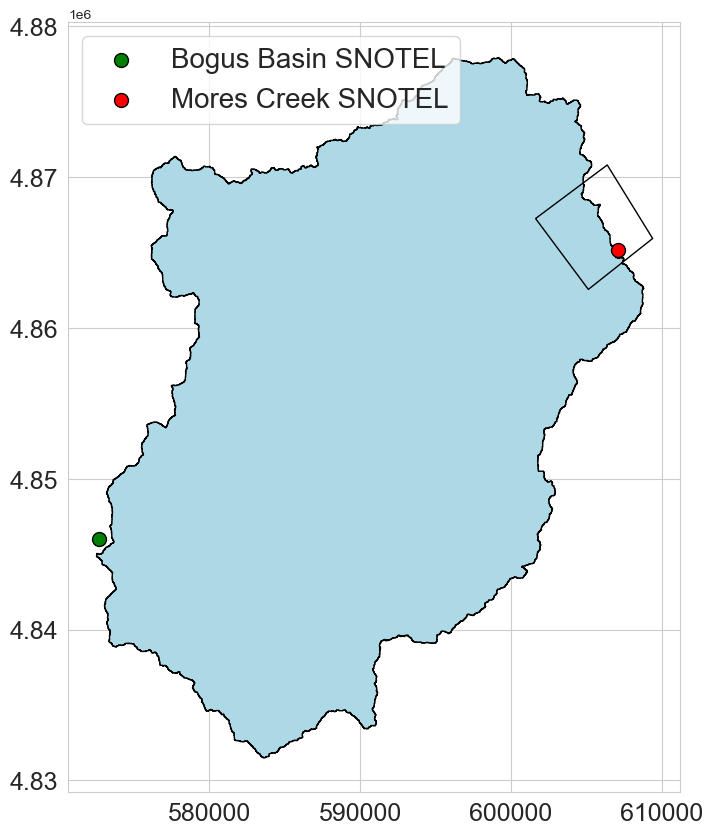

In [12]:
MCS = x_y_snotel(snotel_point_MCS)
BB = x_y_snotel(snotel_point_BB)
MCS_point = Point(MCS)
BB_point = Point(BB)

mcs_shp = gpd.read_file("C:/Users/RDCRLSMC/Desktop/GIS/MCS/MCS_shp/MCS_outline.shp")
basin_shp = gpd.read_file("C:/Users/RDCRLSMC/Desktop/GIS/basin/basin_outline.shp")
MCS_gdf = gpd.GeoDataFrame(index=[0], crs=basin_shp.crs, geometry=[MCS_point])
BB_gdf = gpd.GeoDataFrame(index=[0], crs=basin_shp.crs, geometry=[BB_point])


fig, ax = plt.subplots(figsize=(10, 10))
basin_shp.plot(ax=ax, color='lightblue', edgecolor='black', label='Mores Creek Watershed')
mcs_shp.plot(ax=ax, facecolor='none', edgecolor='black', label='LiDAR Domain')
BB_gdf.plot(ax=ax, color='green', edgecolor='black', markersize = 100, label='Bogus Basin SNOTEL')
MCS_gdf.plot(ax=ax, color='red', markersize = 100, edgecolor='black', label='Mores Creek SNOTEL')

ax.legend(loc='upper left', fontsize = 20)
ax.tick_params(axis='both', labelsize=18)

In [13]:
def get_raster_pixel_value(file, geo_x, geo_y):
    """
    Return value from raster at given geo coordinates
    """
    with gdal.Open(file) as dataset:
        gt = dataset.GetGeoTransform()

        pixel_coords = gdal.ApplyGeoTransform(
            gdal.InvGeoTransform(gt), geo_x, geo_y
        )
        pixel_x, pixel_y = int(pixel_coords[0]), int(pixel_coords[1])

        band = dataset.GetRasterBand(1)

        val_array = band.ReadAsArray(
            xoff=pixel_x, yoff=pixel_y, win_xsize=1, win_ysize=1
        )

        return val_array[0][0]

In [14]:
snotel_df = []
    
for key, rasters in task1_raw_data.items():
    for rasters, filepath in rasters.items():
        MCS_depth = get_raster_pixel_value(filepath, MCS[0], MCS[1])
        BB_depth = get_raster_pixel_value(filepath, BB[0], BB[1])
        
        row = {
            "task" : "task 1",
            "date" : key,
            "model" : rasters,
            "MCS depth" : MCS_depth,
            "BB depth" : BB_depth

        }

        snotel_df.append(row)

for key, rasters in task2_raw_data.items():        
    for rasters, filepath in rasters.items():
        MCS_depth = get_raster_pixel_value(filepath, MCS[0], MCS[1])
        BB_depth = get_raster_pixel_value(filepath, BB[0], BB[1])
        
        row = {
            "task" : "task 2",
            "date" : key,
            "model" : rasters,
            "MCS depth" : MCS_depth,
            "BB depth" : BB_depth

        }

        snotel_df.append(row)

snotel_df = pd.DataFrame(snotel_df)


In [15]:
snotel_df["date"] = pd.to_datetime(snotel_df["date"], format='%Y%m%d')
snotel_df = snotel_df.set_index('date')

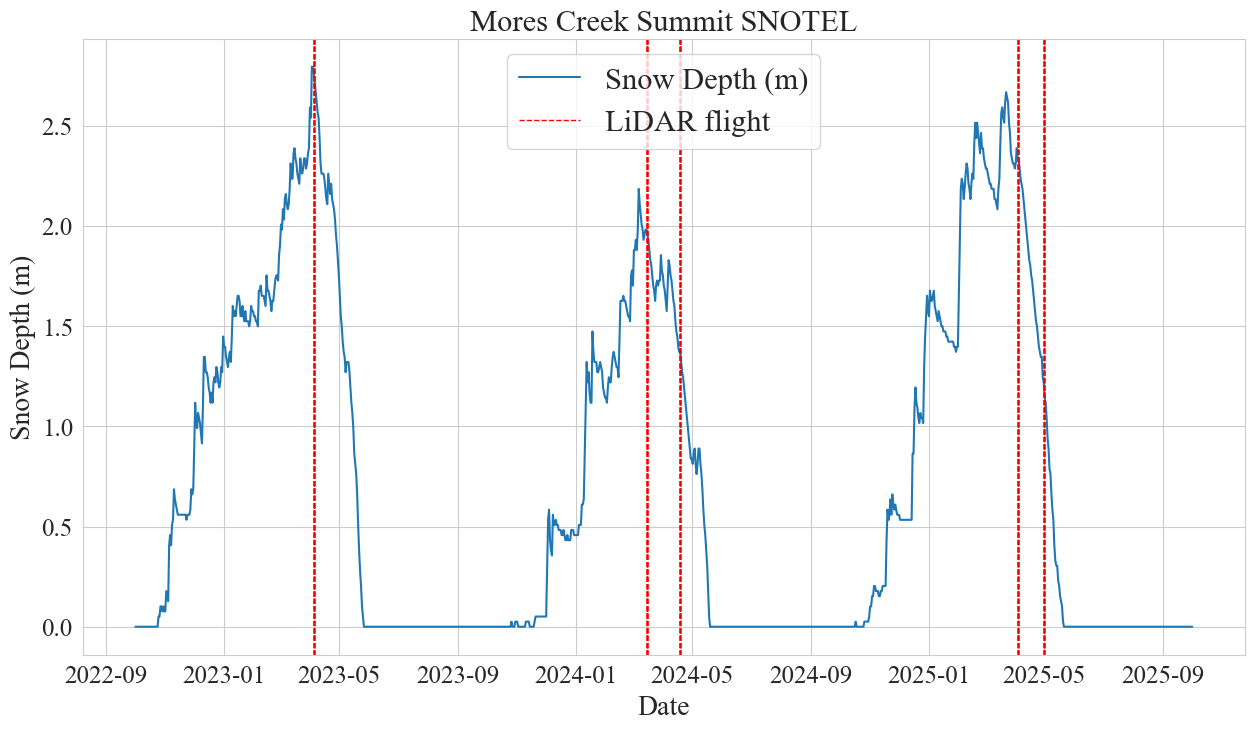

In [38]:
MCS_SNOTEL.columns
dates = MCS_SNOTEL.index.get_level_values('datetime')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']


fig, ax = plt.subplots(figsize=(15, 8))
ax.plot(dates, MCS_SNOTEL['SNOWDEPTH (m)'], label='Snow Depth (m)')
for i, d in enumerate(snotel_df.index):

    ax.axvline(
        x=d,
        color='red',
        linestyle='--',
        linewidth=1,
        label='LiDAR flight' if i == 0 else "_nolegend_"
    )
    
ax.tick_params(axis='both', labelsize=18)
ax.set_ylabel('Snow Depth (m)', fontsize = 20)
ax.set_xlabel('Date', fontsize = 20)
ax.set_title("Mores Creek Summit SNOTEL", fontsize=22)
ax.legend(fontsize = 22)

    

In [17]:
HMS_TI_t1 = snotel_df[
    (snotel_df['model'] == 'HMS_TI') &
    (snotel_df['task'] == 'task 1')
]

HMS_EB_t1 = snotel_df[
    (snotel_df['model'] == 'HMS_EB') &
    (snotel_df['task'] == 'task 1')
]

sm_t1 = snotel_df[
    (snotel_df['model'] == 'Snow Model') &
    (snotel_df['task'] == 'task 1')
]

isno_t1 = snotel_df[
    (snotel_df['model'] == 'iSnobal') &
    (snotel_df['task'] == 'task 1')
]



HMS_TI_t2 = snotel_df[
    (snotel_df['model'] == 'HMS_TI') &
    (snotel_df['task'] == 'task 2')
]

HMS_EB_t2 = snotel_df[
    (snotel_df['model'] == 'HMS_EB') &
    (snotel_df['task'] == 'task 2')
]

sm_t2 = snotel_df[
    (snotel_df['model'] == 'Snow Model') &
    (snotel_df['task'] == 'task 2')
]

isno_t2 = snotel_df[
    (snotel_df['model'] == 'iSnobal') &
    (snotel_df['task'] == 'task 2')
]



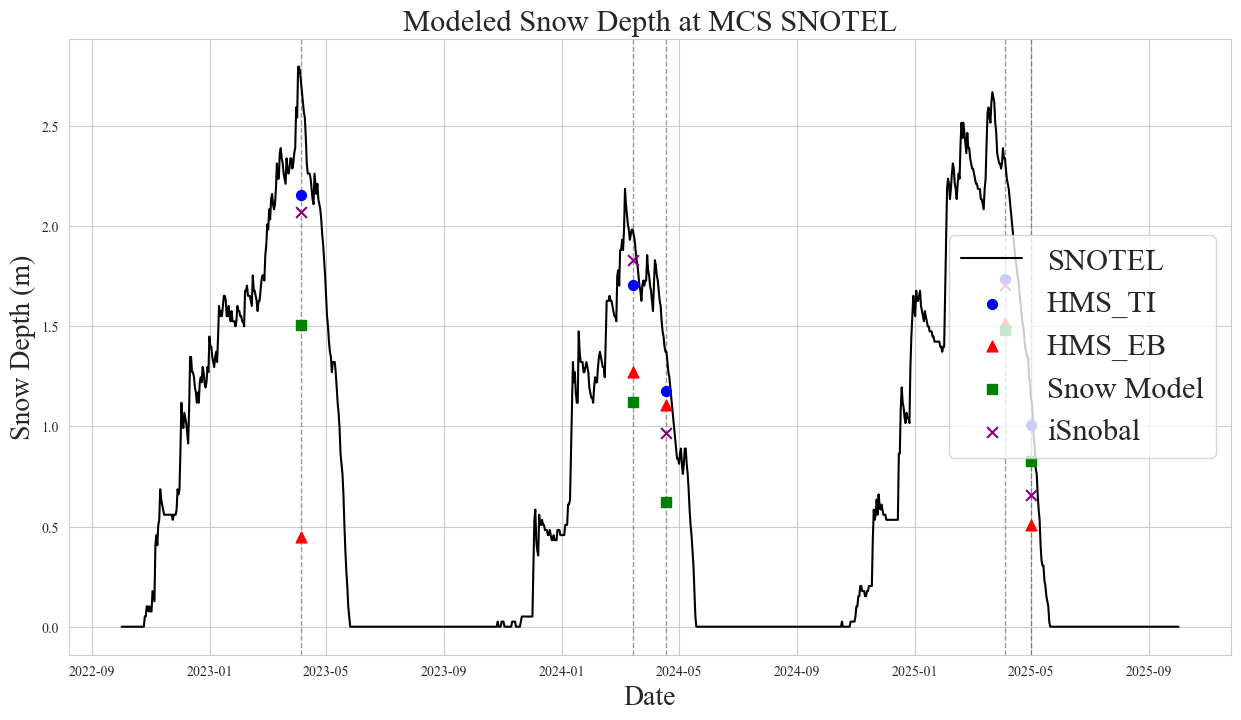

In [18]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

fig, ax = plt.subplots(figsize=(15, 8))
dates = MCS_SNOTEL.index.get_level_values('datetime')

# SNOTEL line
ax.plot(
    dates,
    MCS_SNOTEL['SNOWDEPTH (m)'],
    label='SNOTEL',
    color='black'
)

for i, d in enumerate(HMS_TI_t1.index):
        plt.axvline(
        d,
        color='black',
        linestyle='--',
        linewidth=1,
        alpha = 0.4
    )
# HMS TI (circle)
ax.scatter(
    HMS_TI_t1.index,
    HMS_TI_t1['MCS depth'],
    label='HMS_TI',
    color='blue',
    marker='o',
    s=50,
    zorder=3
)

# HMS EB (triangle up)
ax.scatter(
    HMS_EB_t1.index,
    HMS_EB_t1['MCS depth'],
    label='HMS_EB',
    color='red',
    marker='^',
    s=60,
    zorder=3
)

# Snow Model (square)
ax.scatter(
    sm_t1.index,
    sm_t1['MCS depth'],
    label='Snow Model',
    color='green',
    marker='s',
    s=50,
    zorder=3
)

# iSnobal (x marker)
ax.scatter(
    isno_t1.index,
    isno_t1['MCS depth'],
    label='iSnobal',
    color='purple',
    marker='x',
    s=60,
    zorder=3
)

ax.set_ylabel('Snow Depth (m)', fontsize = 20)
ax.set_xlabel('Date', fontsize = 20)
ax.set_title("Modeled Snow Depth at MCS SNOTEL", fontsize=22)
ax.legend(fontsize = 22)

plt.savefig('C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/MCS_snotel_all.png')


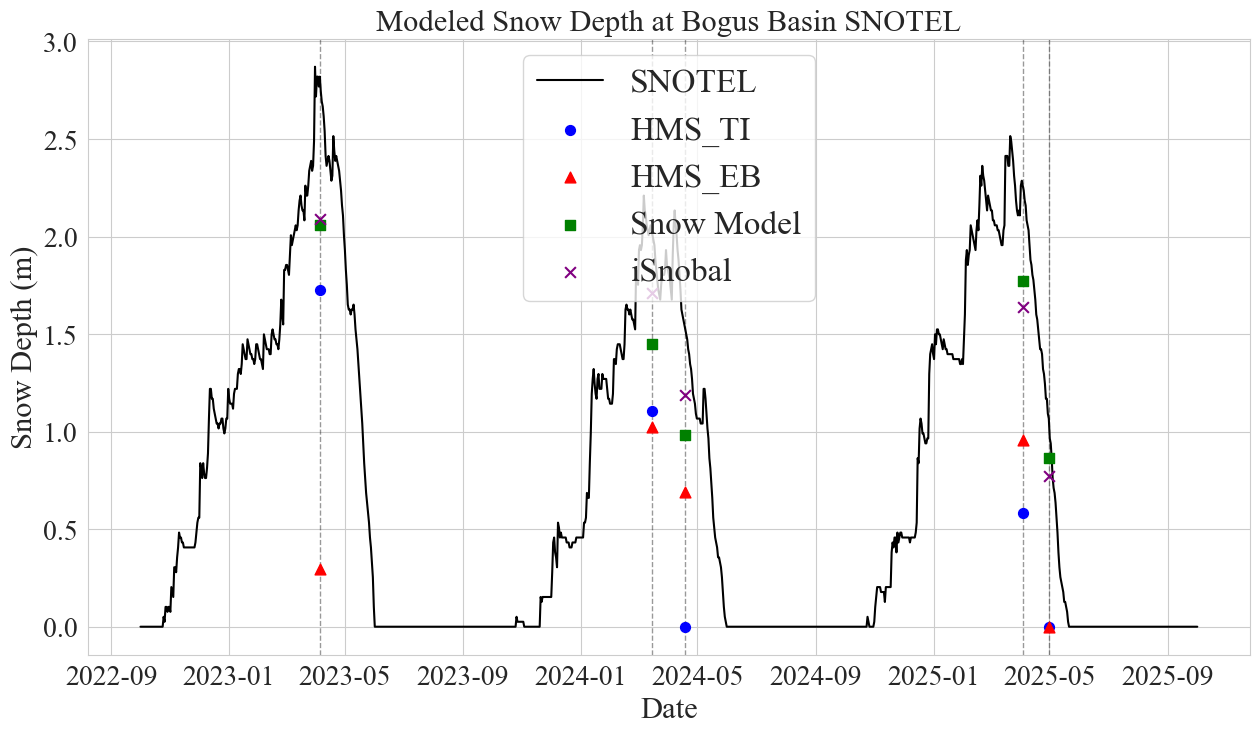

In [19]:
fig, ax = plt.subplots(figsize=(15, 8))
dates = BB_SNOTEL.index.get_level_values('datetime')

# SNOTEL line
ax.plot(
    dates,
    BB_SNOTEL['SNOWDEPTH (m)'],
    label='SNOTEL',
    color='black'
)
for i, d in enumerate(HMS_TI_t1.index):
        plt.axvline(
        d,
        color='black',
        linestyle='--',
        linewidth=1,
        alpha = 0.4
    )
# HMS TI (circle)
ax.scatter(
    HMS_TI_t1.index,
    HMS_TI_t1['BB depth'],
    label='HMS_TI',
    color='blue',
    marker='o',
    s=50,
    zorder=3
)

# HMS EB (triangle up)
ax.scatter(
    HMS_EB_t1.index,
    HMS_EB_t1['BB depth'],
    label='HMS_EB',
    color='red',
    marker='^',
    s=60,
    zorder=3
)

# Snow Model (square)
ax.scatter(
    sm_t1.index,
    sm_t1['BB depth'],
    label='Snow Model',
    color='green',
    marker='s',
    s=50,
    zorder=3
)

# iSnobal (x marker)
ax.scatter(
    isno_t1.index,
    isno_t1['BB depth'],
    label='iSnobal',
    color='purple',
    marker='x',
    s=60,
    zorder=3
)

ax.set_ylabel('Snow Depth (m)', fontsize = 22)
ax.set_xlabel('Date', fontsize = 22)
ax.tick_params(axis='both', labelsize=20)
ax.set_title("Modeled Snow Depth at Bogus Basin SNOTEL", fontsize=22)
ax.legend(fontsize = 24)

plt.savefig('C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/BB_snotel_all.png')

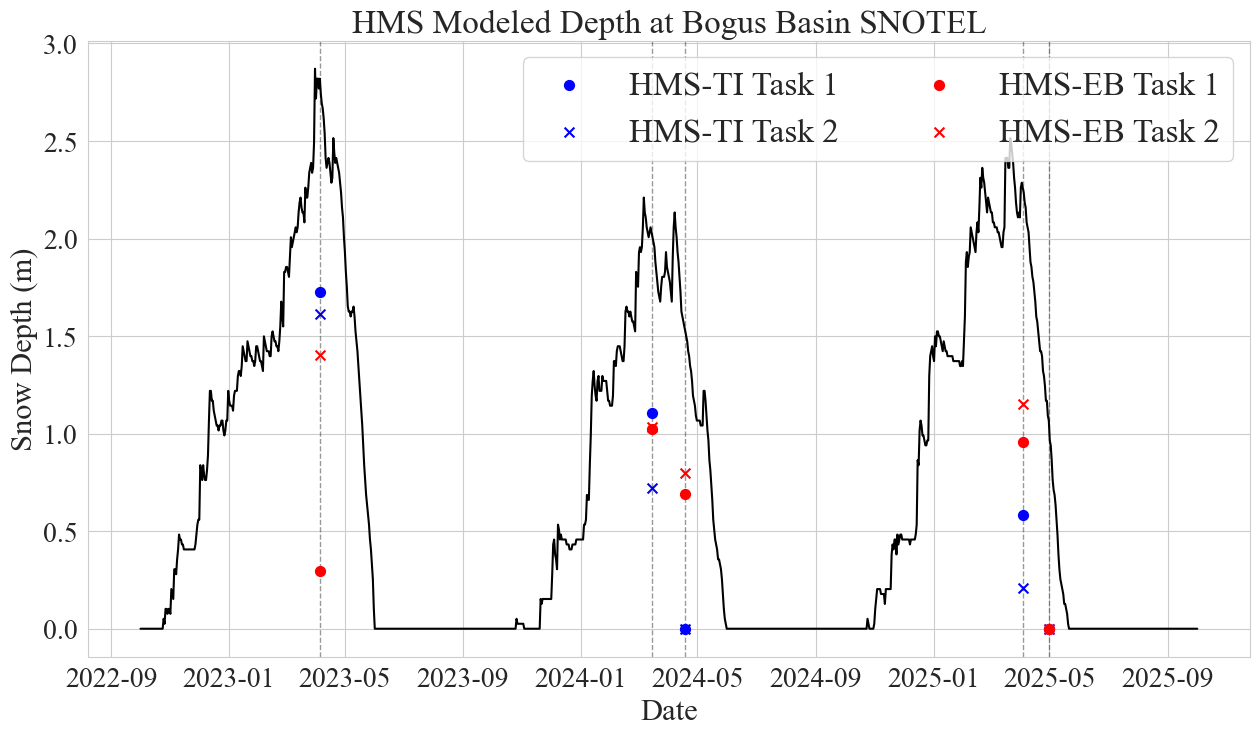

In [20]:
fig, ax = plt.subplots(figsize=(15, 8))
dates = BB_SNOTEL.index.get_level_values('datetime')

# SNOTEL line
ax.plot(
    dates,
    BB_SNOTEL['SNOWDEPTH (m)'],
    #label='SNOTEL',
    color='black'
)
for i, d in enumerate(HMS_TI_t1.index):
        plt.axvline(
        d,
        color='black',
        linestyle='--',
        linewidth=1,
        alpha = 0.4
    )
# HMS TI (circle)
ax.scatter(
    HMS_TI_t1.index,
    HMS_TI_t1['BB depth'],
    label='HMS-TI Task 1',
    color='blue',
    marker='o',
    s=50,
    zorder=3
)

ax.scatter(
    HMS_TI_t2.index,
    HMS_TI_t2['BB depth'],
    label='HMS-TI Task 2',
    color='blue',
    marker='x',
    s=50,
    zorder=1
)

ax.scatter(
    HMS_EB_t1.index,
    HMS_EB_t1['BB depth'],
    label='HMS-EB Task 1',
    color='red',
    marker='o',
    s=50,
    zorder=3
)

ax.scatter(
    HMS_EB_t2.index,
    HMS_EB_t2['BB depth'],
    label='HMS-EB Task 2',
    color='red',
    marker='x',
    s=50,
    zorder=3
)


ax.set_ylabel('Snow Depth (m)', fontsize = 22)
ax.set_xlabel('Date', fontsize = 22)
ax.tick_params(axis='both', labelsize=20)
ax.set_title("HMS Modeled Depth at Bogus Basin SNOTEL", fontsize=24)
ax.legend(fontsize = 24, loc = 'upper right', ncol = 2)

plt.savefig('C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/HMS_BBsnotel.png')

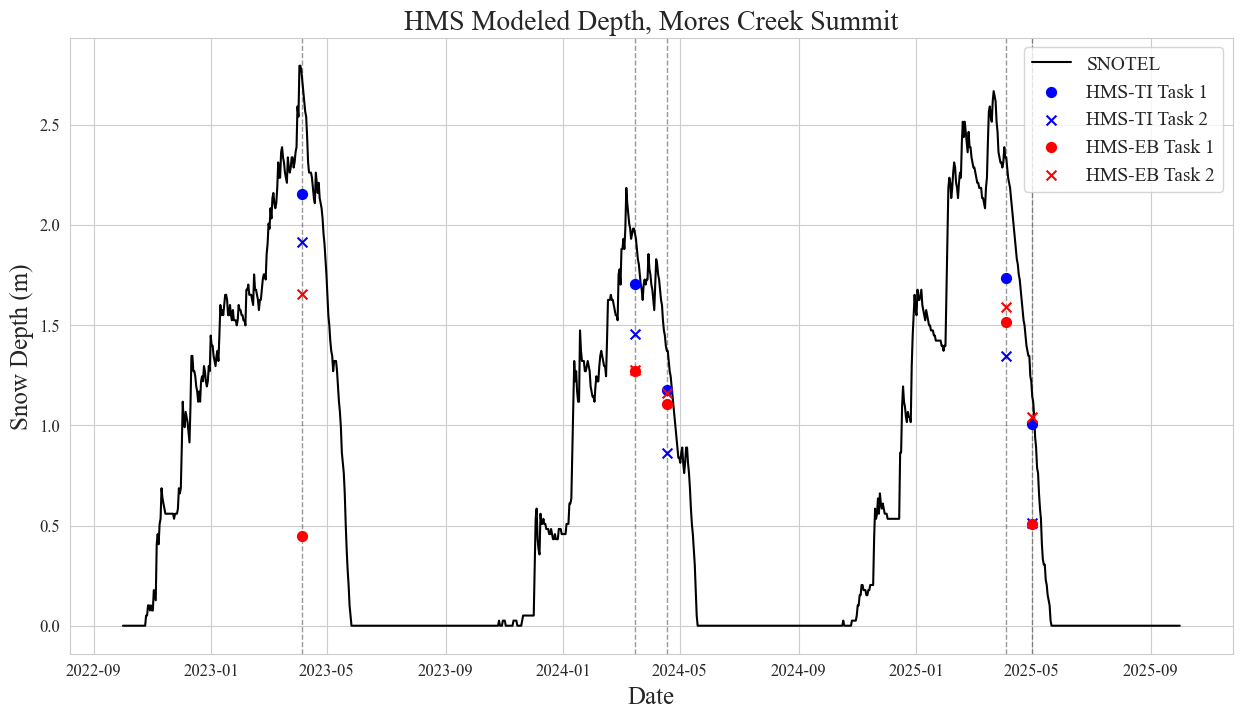

In [21]:
fig, ax = plt.subplots(figsize=(15, 8))
dates = MCS_SNOTEL.index.get_level_values('datetime')

# SNOTEL line
ax.plot(
    dates,
    MCS_SNOTEL['SNOWDEPTH (m)'],
    label='SNOTEL',
    color='black'
)
for i, d in enumerate(HMS_TI_t1.index):
        plt.axvline(
        d,
        color='black',
        linestyle='--',
        linewidth=1,
        alpha = 0.4
    )
# HMS TI (circle)
ax.scatter(
    HMS_TI_t1.index,
    HMS_TI_t1['MCS depth'],
    label='HMS-TI Task 1',
    color='blue',
    marker='o',
    s=50,
    zorder=3
)

ax.scatter(
    HMS_TI_t2.index,
    HMS_TI_t2['MCS depth'],
    label='HMS-TI Task 2',
    color='blue',
    marker='x',
    s=50,
    zorder=1
)

ax.scatter(
    HMS_EB_t1.index,
    HMS_EB_t1['MCS depth'],
    label='HMS-EB Task 1',
    color='red',
    marker='o',
    s=50,
    zorder=3
)

ax.scatter(
    HMS_EB_t2.index,
    HMS_EB_t2['MCS depth'],
    label='HMS-EB Task 2',
    color='red',
    marker='x',
    s=50,
    zorder=3
)

ax.set_ylabel('Snow Depth (m)', fontsize = 18)
ax.set_xlabel('Date', fontsize = 18)
ax.tick_params(axis='both', labelsize=12)
ax.set_title("HMS Modeled Depth, Mores Creek Summit", fontsize=20)
ax.legend(fontsize = 14, loc = 'upper right')

plt.savefig('C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/HMS_MCS_snotel.png')

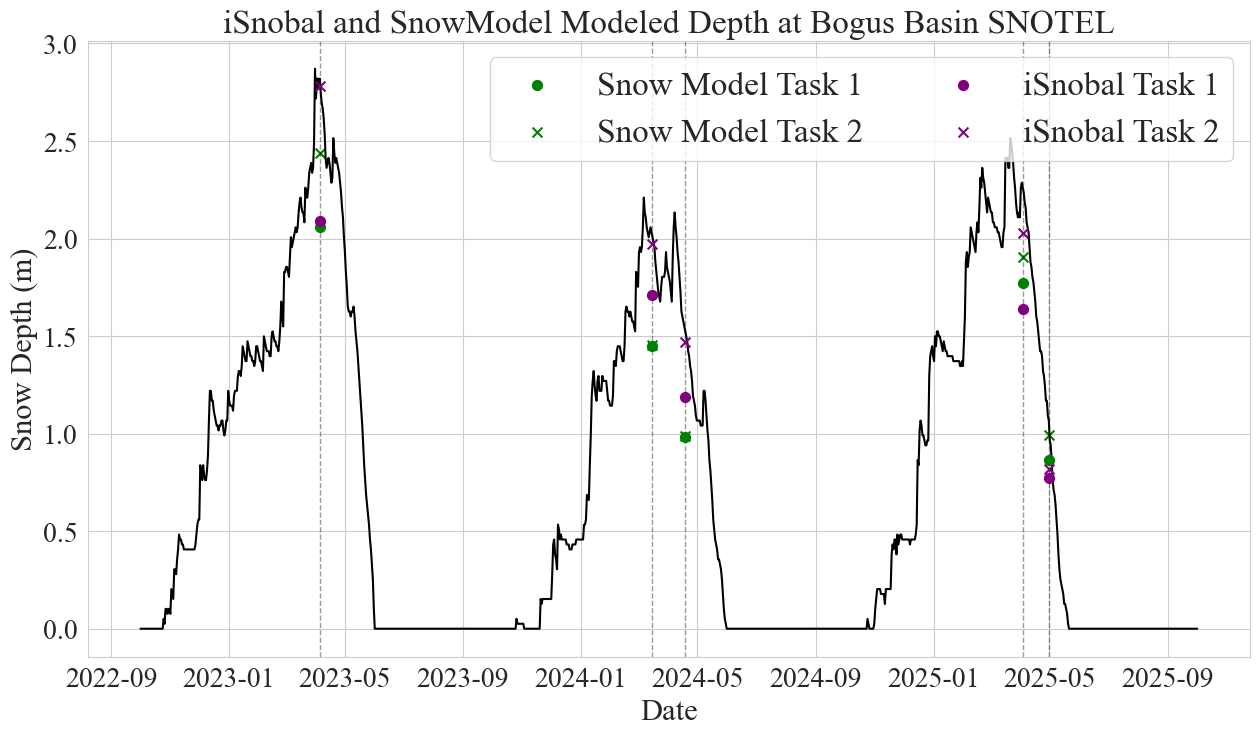

In [22]:
fig, ax = plt.subplots(figsize=(15, 8))
dates = BB_SNOTEL.index.get_level_values('datetime')

# SNOTEL line
ax.plot(
    dates,
    BB_SNOTEL['SNOWDEPTH (m)'],
    #label='SNOTEL',
    color='black'
)
for i, d in enumerate(HMS_TI_t1.index):
        plt.axvline(
        d,
        color='black',
        linestyle='--',
        linewidth=1,
        alpha = 0.4
    )
# HMS TI (circle)
ax.scatter(
    sm_t1.index,
    sm_t1['BB depth'],
    label='Snow Model Task 1',
    color='green',
    marker='o',
    s=50,
    zorder=3
)

ax.scatter(
    sm_t2.index,
    sm_t2['BB depth'],
    label='Snow Model Task 2',
    color='green',
    marker='x',
    s=50,
    zorder=1
)

ax.scatter(
    isno_t1.index,
    isno_t1['BB depth'],
    label='iSnobal Task 1',
    color='purple',
    marker='o',
    s=50,
    zorder=3
)

ax.scatter(
    isno_t2.index,
    isno_t2['BB depth'],
    label='iSnobal Task 2',
    color='purple',
    marker='x',
    s=50,
    zorder=3
)


ax.set_ylabel('Snow Depth (m)', fontsize = 22)
ax.set_xlabel('Date', fontsize = 22)
ax.tick_params(axis='both', labelsize=20)
ax.set_title("iSnobal and SnowModel Modeled Depth at Bogus Basin SNOTEL", fontsize=24)
ax.legend(fontsize = 24, loc = 'upper right', ncol = 2)

plt.savefig('C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/SM_BB_snotel.png')

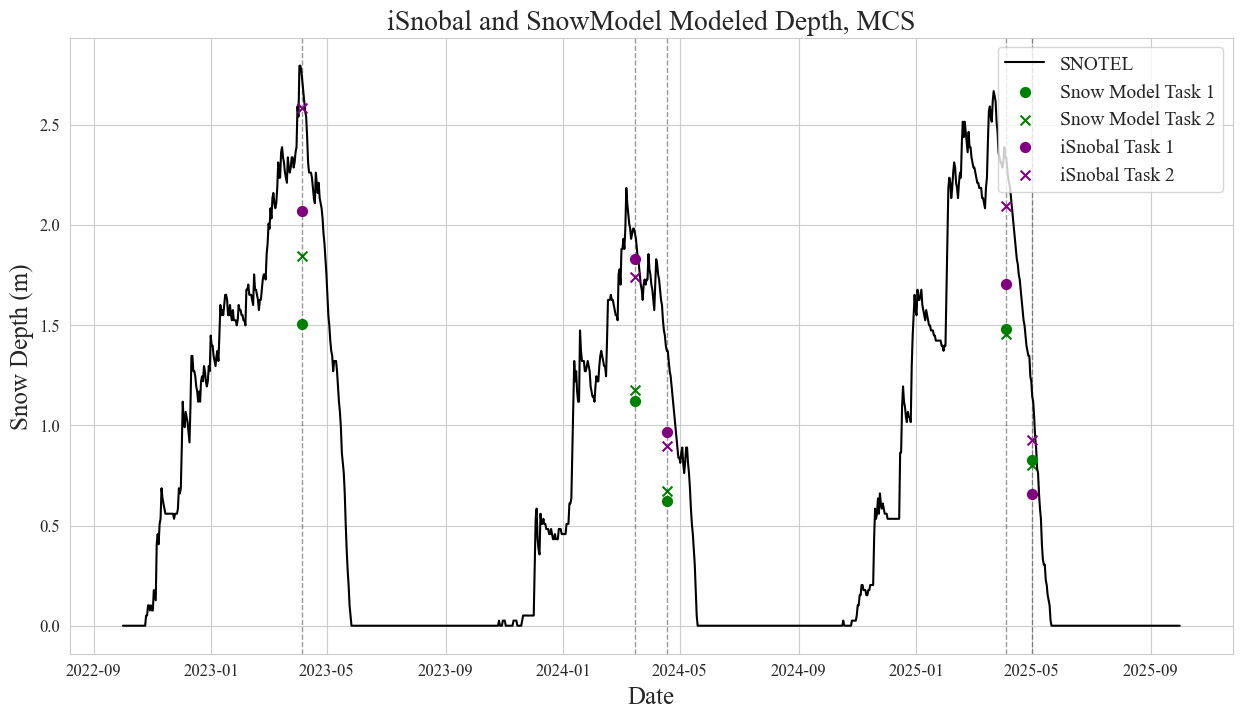

In [24]:
fig, ax = plt.subplots(figsize=(15, 8))
dates = MCS_SNOTEL.index.get_level_values('datetime')

# SNOTEL line
ax.plot(
    dates,
    MCS_SNOTEL['SNOWDEPTH (m)'],
    label='SNOTEL',
    color='black'
)
for i, d in enumerate(HMS_TI_t1.index):
        plt.axvline(
        d,
        color='black',
        linestyle='--',
        linewidth=1,
        alpha = 0.4
    )
# HMS TI (circle)
ax.scatter(
    sm_t1.index,
    sm_t1['MCS depth'],
    label='Snow Model Task 1',
    color='green',
    marker='o',
    s=50,
    zorder=3
)

ax.scatter(
    sm_t2.index,
    sm_t2['MCS depth'],
    label='Snow Model Task 2',
    color='green',
    marker='x',
    s=50,
    zorder=1
)

ax.scatter(
    isno_t1.index,
    isno_t1['MCS depth'],
    label='iSnobal Task 1',
    color='purple',
    marker='o',
    s=50,
    zorder=3
)

ax.scatter(
    isno_t2.index,
    isno_t2['MCS depth'],
    label='iSnobal Task 2',
    color='purple',
    marker='x',
    s=50,
    zorder=3
)


ax.set_ylabel('Snow Depth (m)', fontsize = 18)
ax.set_xlabel('Date', fontsize = 18)
ax.tick_params(axis='both', labelsize=12)
ax.set_title("iSnobal and SnowModel Modeled Depth, MCS", fontsize=20)
ax.legend(fontsize = 14, loc = 'upper right')

plt.savefig('C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/SM_MCS_snotel.png')